<a href="https://colab.research.google.com/github/ShaliniMani14/DATA-SCIENCE-PROJECT/blob/main/movie_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import warnings
from google.colab import userdata
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Ensure compatibility for the surprise library
!pip install numpy==1.26.4

try:
    from surprise import Reader, Dataset, SVD
except ImportError:
    !pip install scikit-surprise
    from surprise import Reader, Dataset, SVD

warnings.filterwarnings('ignore')

# Secure Kaggle Authentication (Ensure these are in your Colab Secrets)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download and Extract Dataset
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d rounakbanik/the-movies-dataset
!unzip -qo the-movies-dataset.zip
print("Dataset ready.")

Dataset URL: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
License(s): CC0-1.0
100% 228M/228M [00:06<00:00, 37.0MB/s]

Dataset ready.


In [ ]:
# Load all necessary files
md = pd.read_csv('movies_metadata.csv', low_memory=False)
credits = pd.read_csv('credits.csv')
keywords = pd.read_csv('keywords.csv')
links = pd.read_csv('links_small.csv')
ratings = pd.read_csv('ratings_small.csv')

# 1. Clean IDs and drop corrupted rows
md = md.drop([19730, 29503, 35587])
md['id'] = md['id'].astype('int')
credits['id'] = credits['id'].astype('int')
keywords['id'] = keywords['id'].astype('int')
links = links.dropna(subset=['tmdbId']).copy()
links['tmdbId'] = links['tmdbId'].astype('int')

# 2. Merge Metadata with Credits and Keywords
md = md.merge(credits, on='id').merge(keywords, on='id')

# 3. LINKING STEP: Merge with links to get 'movieId' (needed for SVD)
md = md.merge(links[['movieId', 'tmdbId']], left_on='id', right_on='tmdbId')

# 4. Process Content
md['overview'] = md['overview'].fillna('')
md['year'] = pd.to_datetime(md['release_date'], errors='coerce').dt.year

print(f"Data ready. Total movies with valid mappings: {md.shape[0]}")

Data ready. Total movies with valid mappings: 9219


In [ ]:
# Filter for movies above the 70th percentile in votes for quality/performance
m = md['vote_count'].quantile(0.70)
md_filtered = md.copy().loc[md['vote_count'] >= m].reset_index(drop=True)

# Build TF-IDF Matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(md_filtered['overview'])

# Compute Plot Similarity
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Create mapping index
indices = pd.Series(md_filtered.index, index=md_filtered['title']).drop_duplicates()

print(f"Content-based engine initialized for {len(md_filtered)} movies.")

Content-based engine initialized for 2767 movies.


In [ ]:
# Setup Surprise Reader
reader = Reader()
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Train the SVD Model
svd = SVD()
trainset = data.build_full_trainset()
svd.fit(trainset)

print("Collaborative filtering engine trained successfully.")

Collaborative filtering engine trained successfully.



--- TOP 10 RECOMMENDATIONS FOR USER 1 ---
Based on your interest in: Toy Story
--------------------------------------------------
                                   title  year    id  predicted_rating
                The Shawshank Redemption  1994   278          3.687007
                             Toy Story 3  2010 10193          3.403044
                             Toy Story 2  1999   863          3.174876
                          Monsters, Inc.  2001   585          3.141044
                               16 Wishes  2010 40205          3.029786
                  The 40 Year Old Virgin  2005  6957          3.006145
                                   Crash  2004  1640          2.965822
                   Rebel Without a Cause  1955   221          2.906672
                             Match Point  2005   116          2.885935
Harry Potter and the Philosopher's Stone  2001   671          2.817396
--------------------------------------------------


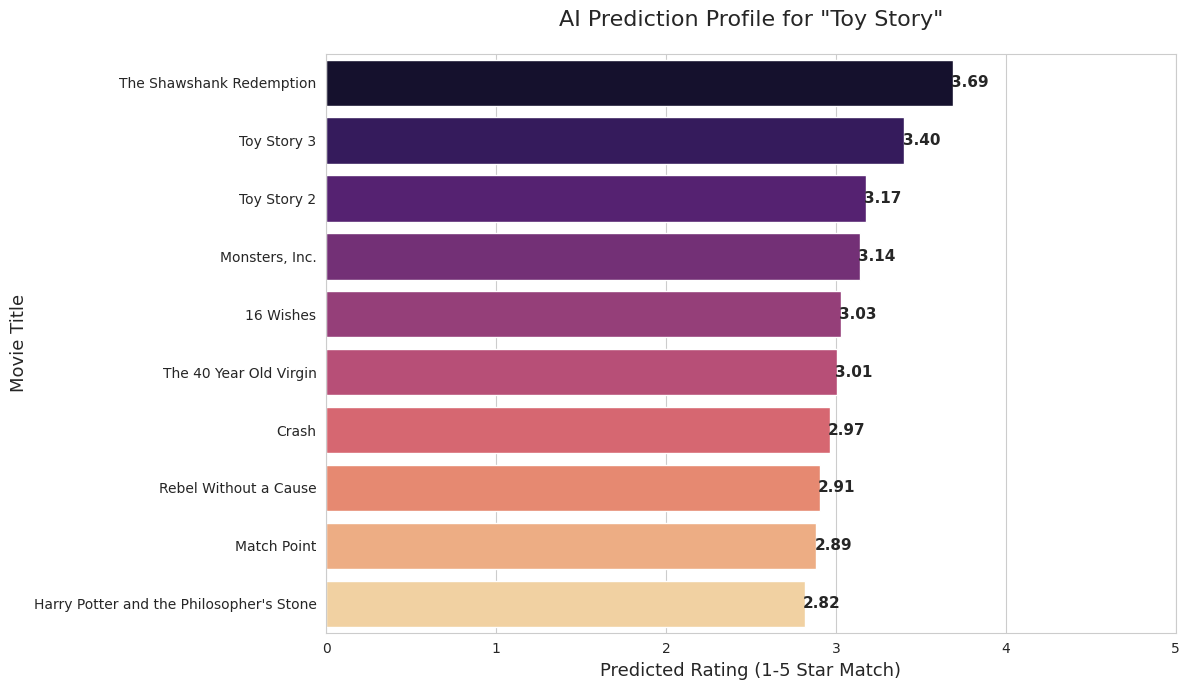

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def hybrid_recommend(userId, title):
    if title not in indices:
        return f"Error: '{title}' not found in the dataset. Please check spelling."

    # 1. Similarity search (Librarian)
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 2. Select top 25 candidates
    movie_indices = [i[0] for i in sim_scores[1:26]]
    candidates = md_filtered.iloc[movie_indices][['title', 'year', 'id', 'movieId']].copy()

    # 3. Personalize (Social Butterfly)
    candidates['predicted_rating'] = candidates['movieId'].apply(lambda x: svd.predict(userId, x).est)

    # Return top 10 ranked by prediction
    return candidates.sort_values('predicted_rating', ascending=False).head(10)

def visualize_results(results, input_movie, userId):
    if not isinstance(results, pd.DataFrame):
        print(f"⚠️ {results}")
        return

    # --- PART 1: PRINT THE TABLE ---
    print(f"\n--- TOP 10 RECOMMENDATIONS FOR USER {userId} ---")
    print(f"Based on your interest in: {input_movie}")
    print("-" * 50)
    # Removing index for a cleaner print
    print(results[['title', 'year', 'id', 'predicted_rating']].to_string(index=False))
    print("-" * 50)

    # --- PART 2: SHOW THE GRAPH ---
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    ax = sns.barplot(x='predicted_rating', y='title', data=results, palette='magma')

    plt.title(f'AI Prediction Profile for "{input_movie}"', fontsize=16, pad=20)
    plt.xlabel('Predicted Rating (1-5 Star Match)', fontsize=13)
    plt.ylabel('Movie Title', fontsize=13)
    plt.xlim(0, 5)

    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}',
                    (p.get_width() + 0.1, p.get_y() + p.get_height()/2),
                    ha='center', va='center', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- FINAL RUN ---
TEST_USER = 1
FAVORITE_MOVIE = 'Toy Story' # Change this to any movie like 'Inception' or 'Avatar'

final_results = hybrid_recommend(TEST_USER, FAVORITE_MOVIE)
visualize_results(final_results, FAVORITE_MOVIE, TEST_USER)